# Bombay Stock Exchange Analysis and Stock Price Prediction



# 1. What was the change in price of the stock overtime?

In this section we'll go over how to handle requesting stock information with pandas, and how to analyze basic attributes of a stock.

In [ ]:
pip install -q yfinance

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.style.use("fast")
%matplotlib inline
from pandas_datareader.data import DataReader
import yfinance as yf
from datetime import datetime

tech_list = ['HUHTAMAKI.BO', 'TCS.BO', 'ONGC.BO', 'COROMANDEL.BO',
             'RELIANCE.BO', 'TATAMOTORS.BO', 'BHEL.BO', 'NESTLEIND.BO']

end = datetime.now()
start = datetime(end.year - 10, end.month, end.day)

# Create a dictionary to store stock data
stock_data = {}

for stock_symbol in tech_list:
    stock_data[stock_symbol] = yf.download(stock_symbol, start, end)

company_list = [stock_data['HUHTAMAKI.BO'], stock_data['TCS.BO'],
                stock_data['ONGC.BO'], stock_data['COROMANDEL.BO'],
                stock_data['RELIANCE.BO'], stock_data['TATAMOTORS.BO'],
                stock_data['BHEL.BO'], stock_data['NESTLEIND.BO']]

company_name = ["HUHTAMAKI", "TCS", "ONGC", "COROMANDEL INT",
                "RELIANCE INDUSTRIES", "TATA MOTORS", "BHEL", "NESTLE INDIA"]

for company, com_name in zip(company_list, company_name):
    company["company_name"] = com_name

df = pd.concat(company_list, axis=0)
df.head(10)

/tmp/ipython-input-14-1411755302.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data[stock_symbol] = yf.download(stock_symbol, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-14-1411755302.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data[stock_symbol] = yf.download(stock_symbol, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-14-1411755302.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data[stock_symbol] = yf.download(stock_symbol, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-14-1411755302.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data[stock_symbol] = yf.download(stock_symbol, start, end)
[*********************100%***********************]  1

Price,Close,High,Low,Open,Volume,company_name,Close,High,Low,Open,...,Close,High,Low,Open,Volume,Close,High,Low,Open,Volume
Ticker,HUHTAMAKI.BO,HUHTAMAKI.BO,HUHTAMAKI.BO,HUHTAMAKI.BO,HUHTAMAKI.BO,,TCS.BO,TCS.BO,TCS.BO,TCS.BO,...,BHEL.BO,BHEL.BO,BHEL.BO,BHEL.BO,BHEL.BO,NESTLEIND.BO,NESTLEIND.BO,NESTLEIND.BO,NESTLEIND.BO,NESTLEIND.BO
Date,,,,,,,,,,,,,,,,,,,,,
2015-07-14,278.888123,287.030825,271.276445,283.579026,32076.0,HUHTAMAKI,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-07-15,277.294952,286.676785,275.170770,278.888109,12728.0,HUHTAMAKI,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-07-16,275.967285,286.145681,275.259234,281.454779,8905.0,HUHTAMAKI,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-07-17,272.604034,278.799581,269.948800,278.799581,8999.0,HUHTAMAKI,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-07-20,267.647583,279.242110,266.762505,272.604025,5341.0,HUHTAMAKI,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-07-21,266.408539,271.719008,265.523461,267.293617,16539.0,HUHTAMAKI,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-07-22,270.745422,272.958118,260.567023,263.045258,6983.0,HUHTAMAKI,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-07-23,267.116547,274.374197,266.408495,270.037320,5467.0,HUHTAMAKI,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Descriptive Statistics about the Data
`.describe()` generates descriptive statistics. Descriptive statistics include those that summarize the central tendency, dispersion, and shape of a dataset’s distribution, excluding `NaN` values.

Analyzes both numeric and object series, as well as `DataFrame` column sets of mixed data types. The output will vary depending on what is provided. Refer to the notes below for more detail.

In [ ]:
# Summary Stats
stock_data['ONGC.BO'].describe()

Price,Close,High,Low,Open,Volume
Ticker,ONGC.BO,ONGC.BO,ONGC.BO,ONGC.BO,ONGC.BO
count,2442.000000,2442.000000,2442.000000,2442.000000,2.442000e+03
mean,129.792481,131.673746,128.166566,130.122717,9.006255e+05
std,59.941265,60.741544,59.193474,60.101544,9.545740e+05
min,42.405392,44.629822,36.579502,42.370080,3.361700e+04
25%,91.910109,93.465642,90.659280,92.250110,3.469072e+05
50%,113.309845,114.871733,111.844520,113.429529,5.819380e+05
75%,136.594936,138.620324,134.822600,136.778282,1.054042e+06
max,324.541626,327.248124,320.363188,327.153171,1.109255e+07


## Information About the Data
`.info()` method prints information about a DataFrame including the index `dtype` and columns, non-null values, and memory usage.

In [ ]:
# General info
stock_data['ONGC.BO'].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2442 entries, 2015-07-14 to 2025-07-11
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, ONGC.BO)   2442 non-null   float64
 1   (High, ONGC.BO)    2442 non-null   float64
 2   (Low, ONGC.BO)     2442 non-null   float64
 3   (Open, ONGC.BO)    2442 non-null   float64
 4   (Volume, ONGC.BO)  2442 non-null   int64  
 5   (company_name, )   2442 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 133.5+ KB


## Closing Price

The closing price is the last price at which the stock is traded during the regular trading day. A stock’s closing price is the standard benchmark used by investors to track its performance over time.

KeyError: 'Adj Close'

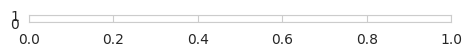

In [ ]:
# Let's see a historical view of the closing price
plt.figure(figsize=(12, 7))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, company in enumerate(company_list, 1):
    plt.subplot(4, 2, i)
    company['Adj Close'].plot(color = "teal")
    plt.ylabel('Adj Close')
    plt.xlabel(None)
    plt.title(f"Closing Price of {tech_list[i - 1]}")

plt.tight_layout()

## Volume of Sales
Volume is the amount of an asset or security that changes hands over some period of time, often over the course of a day. For instance, the stock trading volume would refer to the number of shares of security traded between its daily open and close. Trading volume, and changes to volume over the course of time, are important inputs for technical traders.

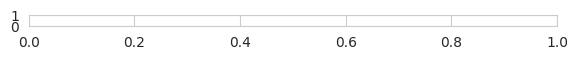

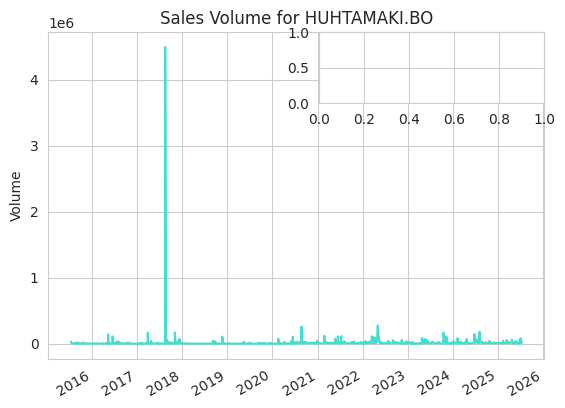

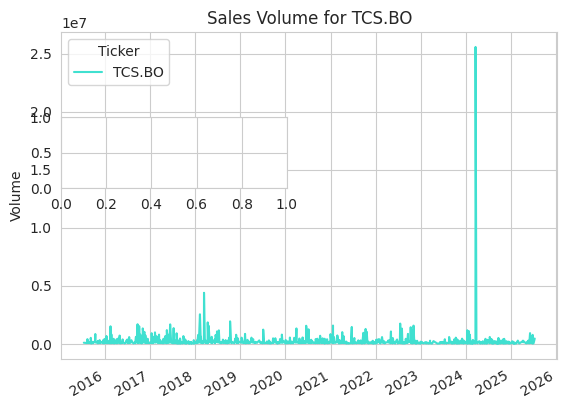

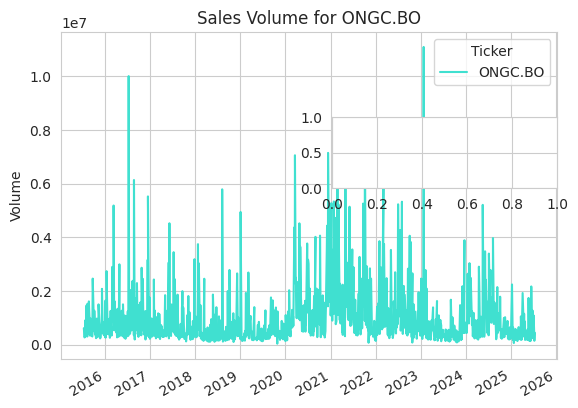

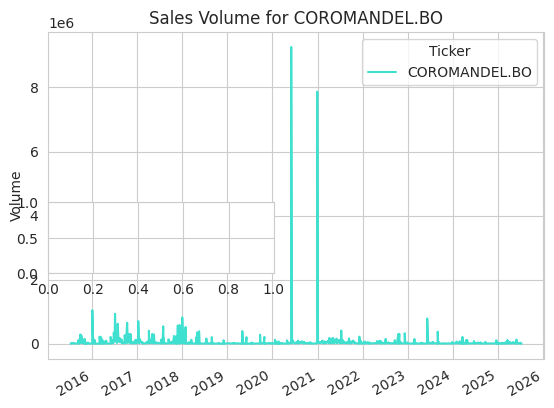

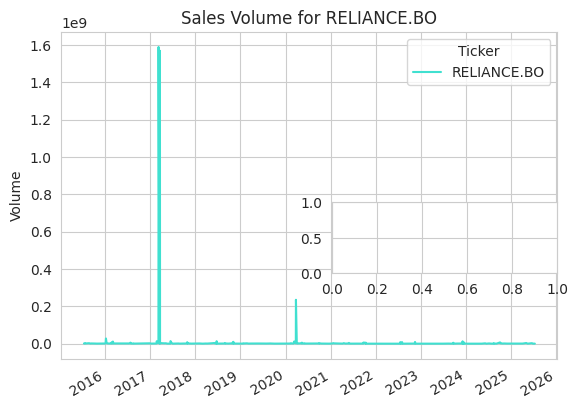

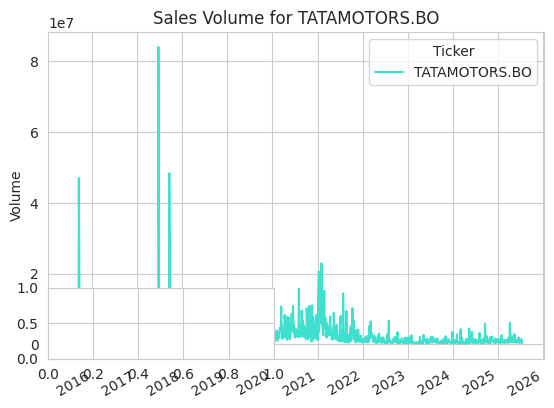

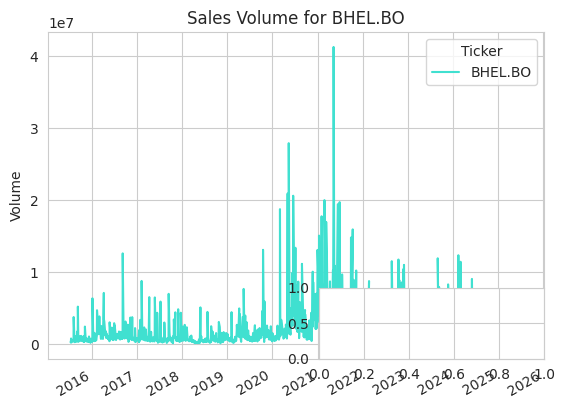

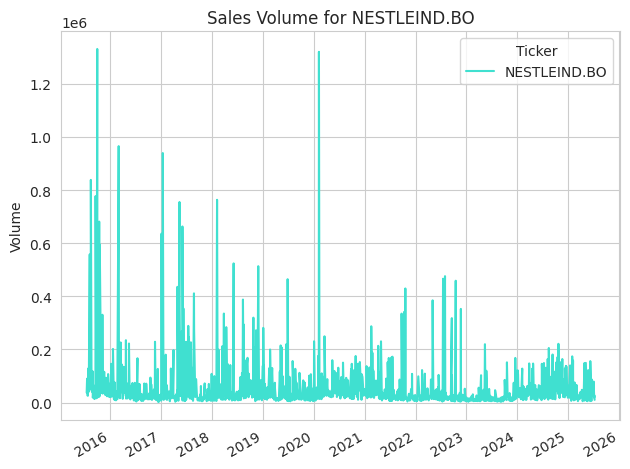

In [ ]:
# Now let's plot the total volume of stock being traded each day
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, company in enumerate(company_list, 1):
    plt.subplot(4, 2, i)
    company['Volume'].plot(color = "turquoise")
    plt.ylabel('Volume')
    plt.xlabel(None)
    plt.title(f"Sales Volume for {tech_list[i - 1]}")

plt.tight_layout()

Now that we've seen the visualizations for the closing price and the volume traded each day, let's go ahead and caculate the moving average for the stock.

# 2. What was the moving average of the various stocks?

The moving average (MA) is a simple technical analysis tool that smooths out price data by creating a constantly updated average price. The average is taken over a specific period of time, like 10 days, 20 minutes, 30 weeks, or any time period the trader chooses.

In [ ]:
ma_day = [10, 20, 50]

for ma in ma_day:
    for company in company_list:
        column_name = f"MA for {ma} days"
        company[column_name] = company['Adj Close'].rolling(ma).mean()


fig, axes = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(10)
fig.set_figwidth(15)

stock_data['HUHTAMAKI.BO'][['Adj Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[0,0])
axes[0,0].set_title('HUHTAMAKI')

stock_data['TCS.BO'][['Adj Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[0,1])
axes[0,1].set_title('TCS')

stock_data['ONGC.BO'][['Adj Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[1,0])
axes[1,0].set_title('ONGC')

stock_data['COROMANDEL.BO'][['Adj Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[1,1])
axes[1,1].set_title('COROMANDEL INTERNATIONAL LTD')

fig.tight_layout()

KeyError: 'Adj Close'

We see in the graph that the best values to measure the moving average are 10 and 20 days because we still capture trends in the data without noise.

# 3. What was the daily return of the stock on average?

Let's get an overall look at the average daily return using a histogram. We'll use seaborn to create both a histogram and kde plot on the same figure.

KeyError: 'Daily Return'

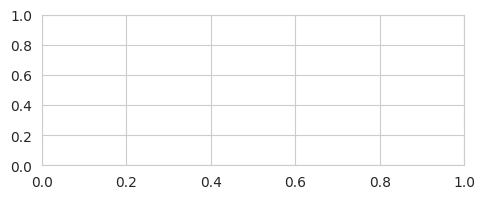

In [ ]:
plt.figure(figsize=(12, 9))

for i, company in enumerate(company_list, 1):
    plt.subplot(4, 2, i)
    company['Daily Return'].hist(bins=50, color="skyblue")
    plt.xlabel('Daily Return')
    plt.ylabel('Counts')
    plt.title(f'{company_name[i - 1]}')

plt.tight_layout()

# 4. What was the correlation between different stocks closing prices?

Correlation is a statistic that measures the degree to which two variables move in relation to each other which has a value that must fall between -1.0 and +1.0. Correlation measures association, but doesn’t show if x causes y or vice versa — or if the association is caused by a third factor[1].

Now what if we wanted to analyze the returns of all the stocks in our list? Let's go ahead and build a DataFrame with all the ['Close'] columns for each of the stocks dataframes.

In [ ]:
# Grab all the closing prices for the tech stock list into one DataFrame

closing_df = pdr.get_data_yahoo(tech_list, start=start, end=end)['Adj Close']

# Make a new tech returns DataFrame
tech_rets = closing_df.pct_change()
tech_rets.head()

/usr/local/lib/python3.11/dist-packages/pandas_datareader/base.py:272: SymbolWarning: Failed to read symbol: 'HUHTAMAKI.BO', replacing with NaN.
  warnings.warn(msg.format(sym), SymbolWarning)
/usr/local/lib/python3.11/dist-packages/pandas_datareader/base.py:272: SymbolWarning: Failed to read symbol: 'TCS.BO', replacing with NaN.
  warnings.warn(msg.format(sym), SymbolWarning)
/usr/local/lib/python3.11/dist-packages/pandas_datareader/base.py:272: SymbolWarning: Failed to read symbol: 'ONGC.BO', replacing with NaN.
  warnings.warn(msg.format(sym), SymbolWarning)
/usr/local/lib/python3.11/dist-packages/pandas_datareader/base.py:272: SymbolWarning: Failed to read symbol: 'COROMANDEL.BO', replacing with NaN.
  warnings.warn(msg.format(sym), SymbolWarning)
/usr/local/lib/python3.11/dist-packages/pandas_datareader/base.py:272: SymbolWarning: Failed to read symbol: 'RELIANCE.BO', replacing with NaN.
  warnings.warn(msg.format(sym), SymbolWarning)
/usr/local/lib/python3.11/dist-packages/pandas

RemoteDataError: No data fetched using 'YahooDailyReader'

# 5. Predicting the closing price stock prices.:

In [ ]:
# Get the stock quote
df_COR = pdr.get_data_yahoo('COROMANDEL.BO', start= datetime(end.year - 10, end.month, end.day), end=datetime.now())
df_HUH = pdr.get_data_yahoo('HUHTAMAKI.BO', start= datetime(end.year - 10, end.month, end.day), end=datetime.now())
df_TCS = pdr.get_data_yahoo('TCS.BO', start= datetime(end.year - 10, end.month, end.day), end=datetime.now())
df_ONGC = pdr.get_data_yahoo('ONGC.BO', start= datetime(end.year - 10, end.month, end.day), end=datetime.now())
df_REL = pdr.get_data_yahoo('RELIANCE.BO', start= datetime(end.year - 10, end.month, end.day), end=datetime.now())
df_TATMO = pdr.get_data_yahoo('TATAMOTORS.BO', start= datetime(end.year - 10, end.month, end.day), end=datetime.now())
df_BHEL = pdr.get_data_yahoo('BHEL.BO', start= datetime(end.year - 10, end.month, end.day), end=datetime.now())
df_NESIND = pdr.get_data_yahoo('NESTLEIND.BO', start= datetime(end.year - 10, end.month, end.day), end=datetime.now())
# Show teh data
df_COR

RemoteDataError: Unable to read URL: https://finance.yahoo.com/quote/COROMANDEL.BO/history?period1=1436846400&period2=1752551999&interval=1d&frequency=1d&filter=history
Response Text:
b'<html><meta charset=\'utf-8\'>\n<script>\nif(window != window.top){\ndocument.write(\'<p>Content is currently unavailable.</p><img src="//geo.yahoo.com/p?s=1197757039&t=\'\n    + new Date().getTime() + \'&_R=\'\n    + encodeURIComponent(document.referrer)\n    + \'&err=404\'\n    + \'" width="0px" height="0px"/>\');\n}else{\nwindow.location.replace(\'https://\' + window.location.host + \'/?err=404\');\n}\n</script>\n<noscript>\n<META http-equiv="refresh" content="0;URL=https://finance.yahoo.com/?err=404">\n</noscript></html>'

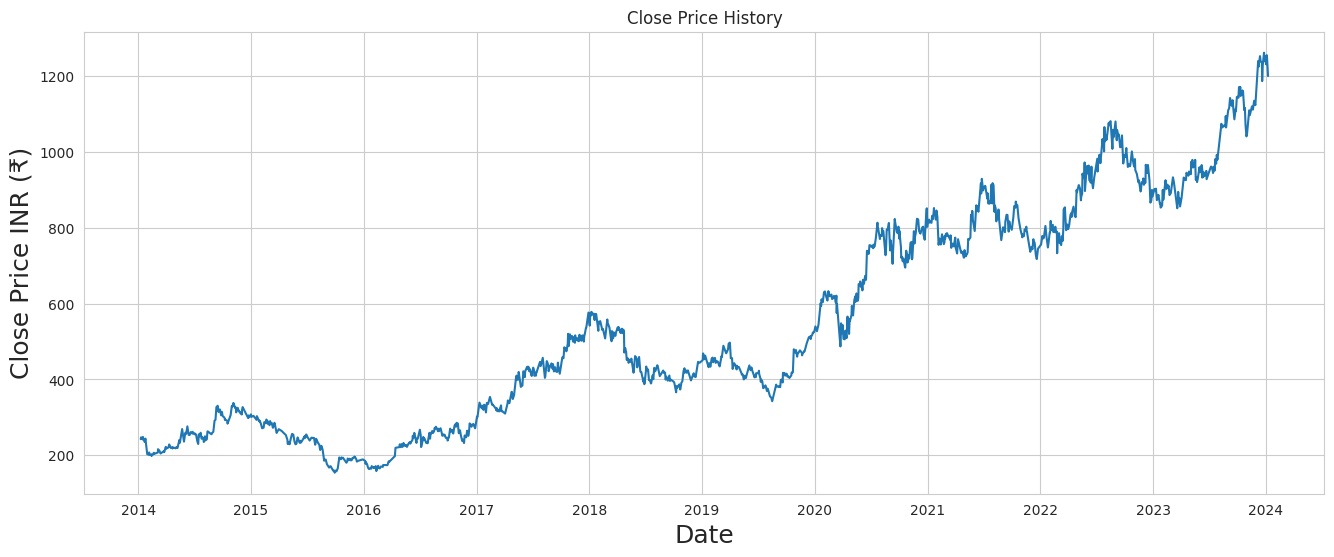

In [ ]:
plt.figure(figsize=(16,6))
plt.title('Close Price History')
plt.plot(df_COR['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price INR (₹)', fontsize=18)
plt.show()

In [ ]:
# Create a new dataframe with only the 'Close column
data = df_COR.filter(['Close'])
# Convert the dataframe to a numpy array
dataset = data.values
# Get the number of rows to train the model on
training_data_len = int(np.ceil( len(dataset) * .95 ))

training_data_len

2319

In [ ]:
# Scale the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(dataset)

scaled_data

array([[-1.06308083],
       [-1.04653159],
       [-1.0544541 ],
       ...,
       [ 2.50363563],
       [ 2.47000879],
       [ 2.30962212]])

In [ ]:
# Create the training data set
# Create the scaled training data set
train_data = scaled_data[0:int(training_data_len), :]
# Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()

# Convert the x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
# x_train.shape

[array([-1.06308083, -1.04653159, -1.0544541 , -1.06448931, -1.06501746,
       -1.04265833, -1.06096819, -1.07470053, -1.07910193, -1.09036949,
       -1.06220055, -1.05815129, -1.13068628, -1.15427782, -1.17610874,
       -1.20357347, -1.20322134, -1.20973543, -1.20762273, -1.18684816,
       -1.20480583, -1.21008751, -1.2072706 , -1.20903116, -1.2033974 ,
       -1.22012271, -1.21131992, -1.21237626, -1.20551004, -1.20128471,
       -1.19001714, -1.2005805 , -1.19811573, -1.19899601, -1.19987629,
       -1.19212984, -1.19776359, -1.19248192, -1.18825658, -1.15656652,
       -1.16818622, -1.16836229, -1.19477067, -1.19547489, -1.18684816,
       -1.19670725, -1.18702417, -1.18720024, -1.18297491, -1.17047493,
       -1.17716508, -1.17452425, -1.18367912, -1.16008764, -1.14529896,
       -1.13508768, -1.14705952, -1.15251726, -1.14529896, -1.14318626])]
[-1.145827102273542]

[array([-1.06308083, -1.04653159, -1.0544541 , -1.06448931, -1.06501746,
       -1.04265833, -1.06096819, -1.07

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=32, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.1))  # Add dropout to prevent overfitting
model.add(LSTM(units=64, return_sequences=True))
model.add(Dropout(0.1))  # Add dropout to prevent overfitting
model.add(LSTM(units=32, return_sequences=False))
model.add(Dropout(0.1))  # Add dropout to prevent overfitting
model.add(Dense(units=1))  # Output layer for regression

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(x_train, y_train, batch_size=1, epochs=50)

Epoch 1/50
2259/2259 [==============================] - 26s 10ms/step - loss: 0.0230
Epoch 2/50
2259/2259 [==============================] - 22s 10ms/step - loss: 0.0147
Epoch 3/50
2259/2259 [==============================] - 22s 10ms/step - loss: 0.0126
Epoch 4/50
2259/2259 [==============================] - 22s 10ms/step - loss: 0.0119
Epoch 5/50
2259/2259 [==============================] - 22s 10ms/step - loss: 0.0114
Epoch 6/50
2259/2259 [==============================] - 21s 9ms/step - loss: 0.0104
Epoch 7/50
2259/2259 [==============================] - 22s 10ms/step - loss: 0.0105
Epoch 8/50
2259/2259 [==============================] - 22s 10ms/step - loss: 0.0099
Epoch 9/50
2259/2259 [==============================] - 21s 9ms/step - loss: 0.0090
Epoch 10/50
2259/2259 [==============================] - 22s 10ms/step - loss: 0.0094
Epoch 11/50
2259/2259 [==============================] - 22s 10ms/step - loss: 0.0085
Epoch 12/50
2259/2259 [==============================] - 22s 10ms

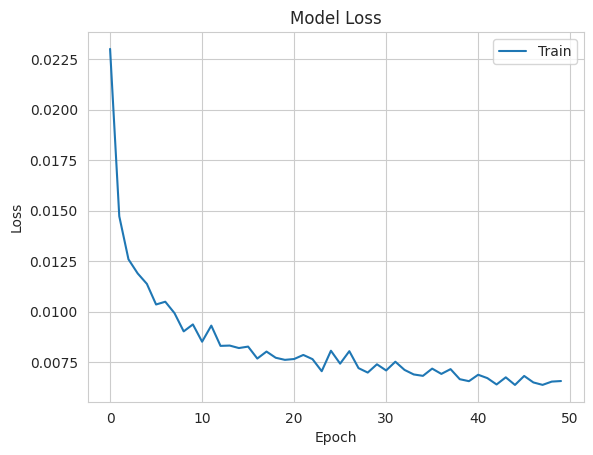

In [ ]:
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper right')
plt.show()

In [ ]:
# Create a new dataframe with only the 'Close column
data = df_NESIND.filter(['Close'])
# Convert the dataframe to a numpy array
dataset = data.values
# Get the number of rows to train the model on
'''training_data_len = int(np.ceil( len(dataset) * .95 ))

training_data_len'''
scaled_data = scaler.fit_transform(dataset)

scaled_data
print(len(scaled_data))

2463


In [ ]:
# Create the testing data set
test_data = scaled_data[training_data_len - 60: , :]
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

# Get the models predicted price values
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

5/5 [==============================] - 0s 7ms/step


108.24297118551617

<ipython-input-161-909b12d15c87>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


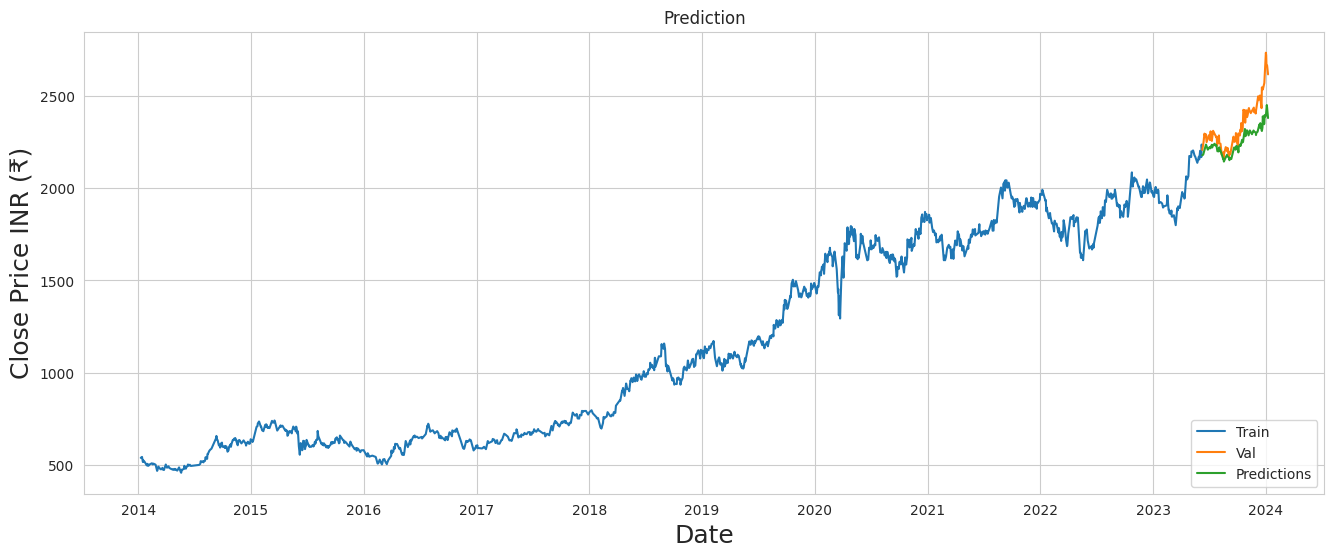

In [ ]:
# Plot the data
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Prediction')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price INR (₹)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

In [ ]:
# Show the valid and predicted prices
valid

,Close,Predictions
Date,,
2023-06-09,2208.794922,2179.993652
2023-06-12,2229.014893,2183.159180
2023-06-13,2249.534912,2190.636475
2023-06-14,2272.445068,2198.290527
2023-06-15,2296.000000,2217.986572
...,...,...
2024-01-02,2723.090088,2452.129395
2024-01-03,2664.034912,2439.326660
2024-01-04,2711.600098,2452.343994


In [ ]:
cum_actual = ((valid['Close'][143] - valid['Close'][0]) / valid['Close'][0]) * 100
print("Cummulative returns actual:", cum_actual)

Cummulative returns actual: 18.580494967296048


In [ ]:
cum_actual = ((valid['Predictions'][143] - valid['Predictions'][0]) / valid['Predictions'][0]) * 100
print("Cummulative returns Predicted:", cum_actual)

Cummulative returns Predicted: 9.269183874130249
